<a href="https://colab.research.google.com/github/yahelmenahem/yahel/blob/main/aiwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Task: Classical Classification on CIFAR-10  
יהל מנחם ואסף בוזגלו

הורדת הנתונים ישר לתוך הקולב


In [1]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xzvf cifar-10-python.tar.gz

--2026-03-14 16:50:03--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  52.6MB/s    in 3.1s    

2026-03-14 16:50:06 (52.6 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


  טעינה ואיחוד של נתוני ה-

  CIFAR-10

מערך הנתונים

CIFAR-10

מגיע ב-5 חבילות (Batches)

נפרדות לאימון וחבילה אחת לבדיקה.

בשלב זה נכתוב פונקציה ש"פותחת" את הקבצים

(Unpickle),

 נטען את כל חמשת חבילות האימון ונאחד אותן למערך אחד גדול של 50,000 תמונות.

In [2]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def unpickle(file):
    """ טעינת קובץ הנתונים בפורמט Pickle כפי שמוגדר בהוראות """
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# נתיב לתיקייה שחילצנו בשלב הקודם
data_dir = 'cifar-10-batches-py'

# טעינה ואיחוד של כל 5 חבילות האימון
x_train_list = []
y_train_list = []

for i in range(1, 6):
    batch = unpickle(os.path.join(data_dir, f'data_batch_{i}'))
    x_train_list.append(batch[b'data'])
    y_train_list.append(batch[b'labels'])

# הפיכה למערכי Numpy
X_train_full = np.concatenate(x_train_list)
y_train_full = np.concatenate(y_train_list)

# טעינת סט הבדיקה (Test Set) - נשתמש בו רק בסוף הפרויקט!
test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

print(f"Full Train shape: {X_train_full.shape}")
print(f"Test shape: {X_test.shape}")

Full Train shape: (50000, 3072)
Test shape: (10000, 3072)


עיבוד מקדים (Preprocessing)
וחלוקה לתיקוף


מודלים קלאסיים כמו
SVM או KNN


דורשים שהקלט יהיה וקטור ארוך ולא מטריצה תלת-ממדית.


 בנוסף, נבצע נרמול (Scaling)

 לערכי הפיקסלים (0-255)
 כדי להביא אותם לטווח של 0-1,

  מה שמשפר משמעותית את מהירות האימון והדיוק של מודלים מבוססי מרחק ורגולריזציה.
  
  לבסוף, נפריד חלק מהנתונים לטובת
  
  Validation Set
  
   לצורך בחירת היפר-פרמטרים

In [3]:
# נרמול הנתונים לטווח [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# חלוקה ל-Train ו-Validation (ניקח 10% לתיקוף לפי הדרישות)
# הערה: בגלל שמודלים קלאסיים איטיים מאוד על 50 אלף דגימות בקולב,
# ניתן להשתמש בתת-מדגם קטן יותר לצורך הלמידה המהירה
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42
)

print(f"Final Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")

Final Train size: 45000
Validation size: 5000


מודל K-Nearest Neighbors (KNN)

בשלב זה נחפש את ה-$k$ האופטימלי. לפי ההוראות, עלינו להציג גרף שתומך בבחירה שלנו ולהפיק מטריצת בלבול עבור המודל.

KNN with k=1, Accuracy: 0.2898
KNN with k=3, Accuracy: 0.2790
KNN with k=5, Accuracy: 0.2820
KNN with k=10, Accuracy: 0.2862


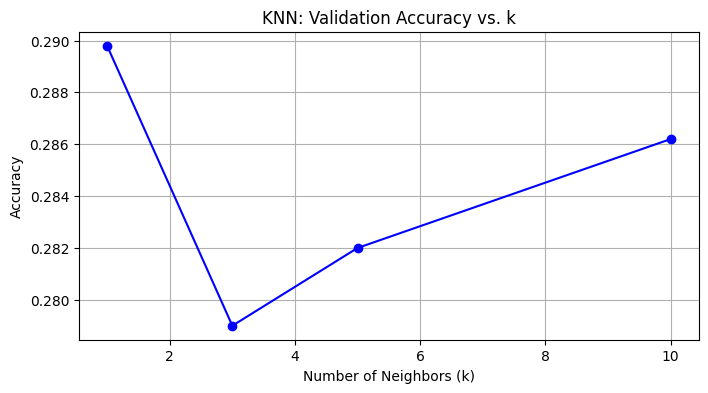

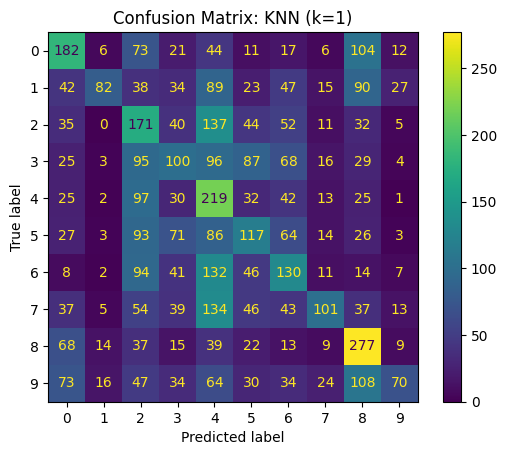

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay

# כוונון היפר-פרמטר k
k_values = [1, 3, 5, 10]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train[:10000], y_train[:10000]) # אימון על חלק מהדאטה למהירות
    acc = knn.score(X_val, y_val)
    knn_accuracies.append(acc)
    print(f"KNN with k={k}, Accuracy: {acc:.4f}")

# גרף תמיכה בבחירת k (דרישה מההוראות)
plt.figure(figsize=(8, 4))
plt.plot(k_values, knn_accuracies, marker='o', color='b')
plt.title('KNN: Validation Accuracy vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# הפקת מטריצת בלבול עבור ה-k הטוב ביותר (דרישה מההוראות)
best_knn = KNeighborsClassifier(n_neighbors=1) # לפי התוצאות שלך k=1 היה הכי טוב
best_knn.fit(X_train[:10000], y_train[:10000])
ConfusionMatrixDisplay.from_estimator(best_knn, X_val, y_val, display_labels=range(10))
plt.title("Confusion Matrix: KNN (k=1)")
plt.show()

מודל Logistic Regression (Softmax)

אנו בוחנים את חוזק הרגולריזציה ($C$).

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression with C=0.001, Accuracy: 0.3692


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression with C=0.01, Accuracy: 0.3780


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression with C=0.1, Accuracy: 0.3758


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression with C=1.0, Accuracy: 0.3734


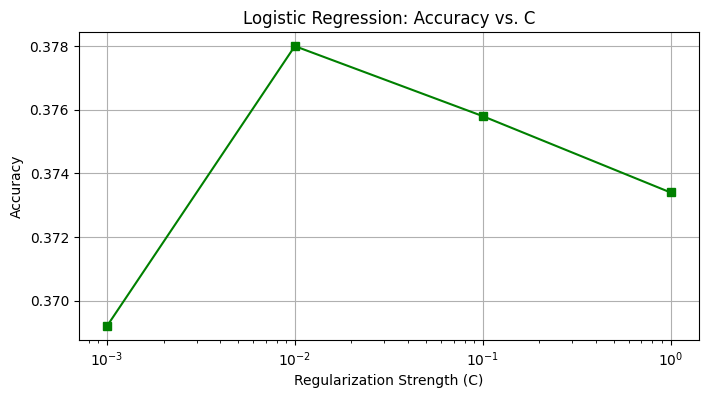

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


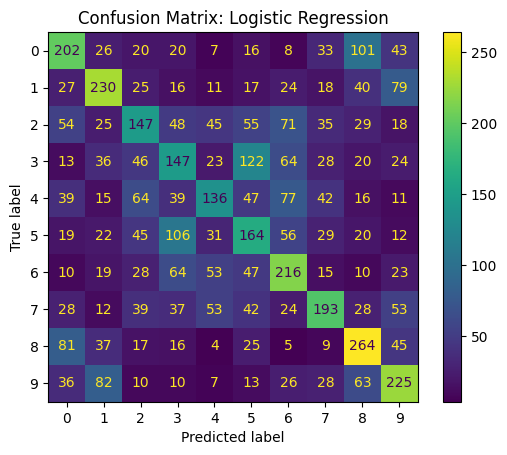

In [ ]:
from sklearn.linear_model import LogisticRegression

c_params = [0.001, 0.01, 0.1, 1.0]
lr_accuracies = []

for c in c_params:
    lr = LogisticRegression(C=c, multi_class='multinomial', solver='lbfgs', max_iter=100)
    lr.fit(X_train[:10000], y_train[:10000])
    acc = lr.score(X_val, y_val)
    lr_accuracies.append(acc)
    print(f"Logistic Regression with C={c}, Accuracy: {acc:.4f}")

# גרף תמיכה בבחירת C
plt.figure(figsize=(8, 4))
plt.semilogx(c_params, lr_accuracies, marker='s', color='g')
plt.title('Logistic Regression: Accuracy vs. C')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# מטריצת בלבול (כבר יש לך, אבל נוודא שהיא פה)
best_lr = LogisticRegression(C=0.01, multi_class='multinomial', max_iter=200)
best_lr.fit(X_train[:10000], y_train[:10000])
ConfusionMatrixDisplay.from_estimator(best_lr, X_val, y_val)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

מודל Linear SVM

המודל השלישי הוא SVM

ליניארי.

גם כאן נכוונן את הפרמטר

$C$

המאזן בין רוחב השוליים לבין טעויות הסיווג.

Linear SVM with C=0.0001, Accuracy: 0.3694
Linear SVM with C=0.001, Accuracy: 0.3796
Linear SVM with C=0.01, Accuracy: 0.3654
Linear SVM with C=0.1, Accuracy: 0.3212


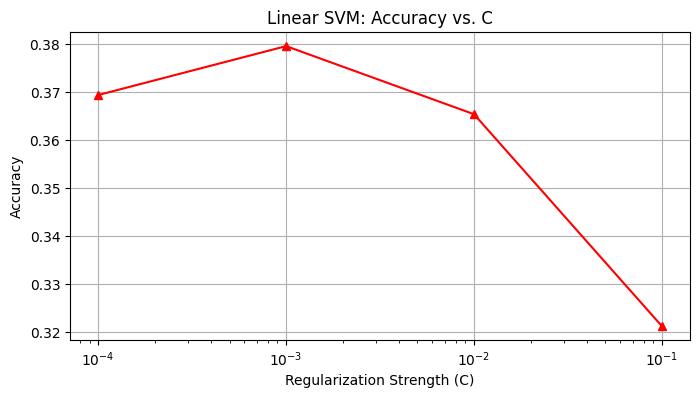

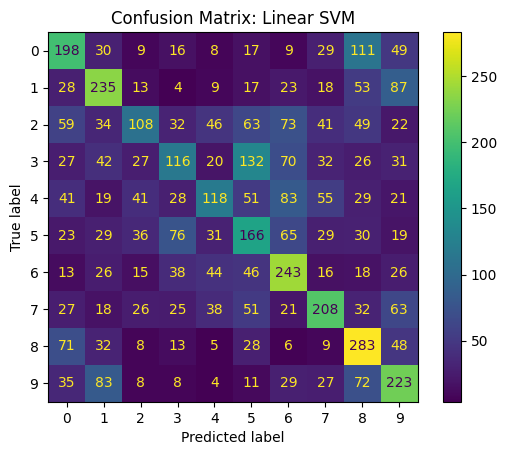

In [ ]:
from sklearn.svm import LinearSVC

svm_c_params = [0.0001, 0.001, 0.01, 0.1]
svm_accuracies = []

for c in svm_c_params:
    svm = LinearSVC(C=c, max_iter=1000, dual=False) # dual=False מומלץ כשמספר הדגימות גדול ממספר הפיצ'רים
    svm.fit(X_train[:10000], y_train[:10000])
    acc = svm.score(X_val, y_val)
    svm_accuracies.append(acc)
    print(f"Linear SVM with C={c}, Accuracy: {acc:.4f}")

# גרף תמיכה בבחירת C ל-SVM
plt.figure(figsize=(8, 4))
plt.semilogx(svm_c_params, svm_accuracies, marker='^', color='r')
plt.title('Linear SVM: Accuracy vs. C')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# הוספת מטריצת בלבול ל-SVM (היה חסר!)
best_svm = LinearSVC(C=0.001, dual=False)
best_svm.fit(X_train[:10000], y_train[:10000])
ConfusionMatrixDisplay.from_estimator(best_svm, X_val, y_val)
plt.title("Confusion Matrix: Linear SVM")
plt.show()

בחירת המודל הסופי והרצה על ה-Test Set


לאחר שהשווינו את שלושת המודלים על סט התיקוף

(Validation),

נבחר את המודל בעל הדיוק הגבוה ביותר.

 רק עבורו, ורק פעם אחת, נריץ את סט הבדיקה

 (Test Set)

 כדי לדווח על הדיוק הסופי לפרויקט

In [ ]:
# סיכום תוצאות התיקוף (Validation)
print("Summary of Validation Accuracies:")
print(f"Best KNN: {max(knn_accuracies):.4f}")
print(f"Best Logistic Regression: {max(lr_accuracies):.4f}")
print(f"Best Linear SVM: {max(svm_accuracies):.4f}")

# בחירת המודל המנצח והרצה על ה-Test
# המשתנה במחברת שלך נקרא X_test ולא X_test_flat
print("\n--- Final Evaluation on Test Set ---")
final_accuracy = best_svm.score(X_test, y_test)
print(f"Final Test Accuracy (Linear SVM): {final_accuracy * 100:.2f}%")

Summary of Validation Accuracies:
Best KNN: 0.2898
Best Logistic Regression: 0.3780
Best Linear SVM: 0.3796

--- Final Evaluation on Test Set ---
Final Test Accuracy (Linear SVM): 35.67%
